In [30]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

In [31]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/kwa_creditcard_dir/creditcard.csv", on_bad_lines='skip')

# Quick check
print(df.shape)
df.head()

/tmp/ipykernel_2934/1668320886.py:2: DtypeWarning: Columns (0,1,2,3,4,5,7,9,12,15,17,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/kwa_creditcard_dir/creditcard.csv", on_bad_lines='skip')


(513953, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363786969611213,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.16648,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425128109186,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.37978,-0.503198,1.800499,0.791461,0.247676,-1.51465432260583,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.38702406270197,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739308235294,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


Class
0.0    513018
1.0       828
Name: count, dtype: int64


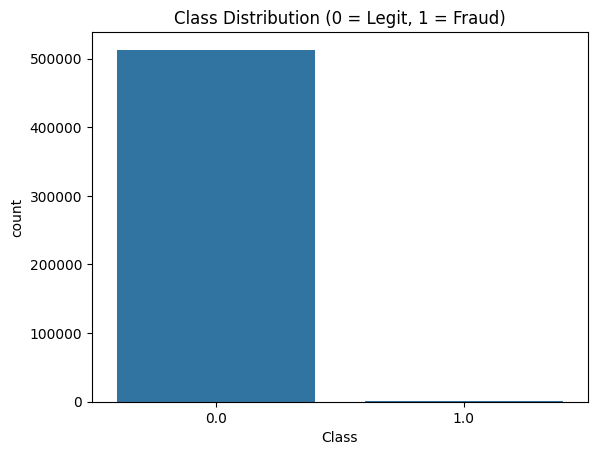

In [32]:
# Class distribution
print(df['Class'].value_counts())

sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Legit, 1 = Fraud)")
plt.show()

In [33]:
# Re-load dataset to ensure 'Amount' and 'Time' columns are present
df = pd.read_csv("/content/drive/MyDrive/kwa_creditcard_dir/creditcard.csv", on_bad_lines='skip')

# Convert 'Time' and 'V' columns to numeric, coercing errors
df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
v_columns = [col for col in df.columns if col.startswith('V')]
for col in v_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with NaN values that resulted from coercion (or handle them differently if preferred)
df.dropna(inplace=True)

scaler = StandardScaler()

df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

# Scale 'Time' and 'V' columns
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

for col in v_columns:
    df[col] = scaler.fit_transform(df[[col]])

df = df.drop(['Amount', 'Time'], axis=1)

/tmp/ipykernel_2934/3060451722.py:2: DtypeWarning: Columns (0,1,2,3,4,5,7,9,12,15,17,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/kwa_creditcard_dir/creditcard.csv", on_bad_lines='skip')


In [34]:
X = df.drop('Class', axis=1)
y = df['Class']

In [35]:
import numpy as np

# Drop rows where 'Class' (y) is NaN
valid_indices = y.dropna().index
X = X.loc[valid_indices]
y = y.loc[valid_indices]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [36]:
rus = RandomUnderSampler(random_state=42)

X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print("After undersampling:", np.bincount(y_train_rus))

After undersampling: [662 662]


In [37]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE:", np.bincount(y_train_smote))

After SMOTE: [410414 410414]


In [38]:
class_weight = {0:1, 1:10}

In [44]:
lr_model = LogisticRegression(max_iter=100)

# Train on SMOTE data (example)
lr_model.fit(X_train_smote, y_train_smote)

LogisticRegression()

In [45]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight={0:1, 1:10}
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 1, 1: 10}, random_state=42)

In [47]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

In [49]:
print("Logistic Regression Results:")
evaluate_model(lr_model, X_test, y_test)

Logistic Regression Results:
Confusion Matrix:
[[100034   2570]
 [    19    147]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.99    102604
         1.0       0.05      0.89      0.10       166

    accuracy                           0.97    102770
   macro avg       0.53      0.93      0.54    102770
weighted avg       1.00      0.97      0.99    102770

Precision: 0.05410379094589621
Recall: 0.8855421686746988
F1 Score: 0.10197710718002082
ROC-AUC: 0.9762144363192117


In [50]:
print("Random Forest Results:")
evaluate_model(rf_model, X_test, y_test)

Random Forest Results:
Confusion Matrix:
[[102604      0]
 [    14    152]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    102604
         1.0       1.00      0.92      0.96       166

    accuracy                           1.00    102770
   macro avg       1.00      0.96      0.98    102770
weighted avg       1.00      1.00      1.00    102770

Precision: 1.0
Recall: 0.9156626506024096
F1 Score: 0.9559748427672956
ROC-AUC: 0.9725211809774671


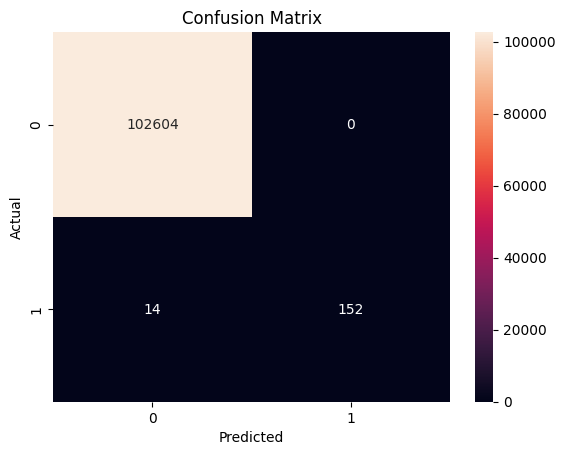

In [52]:
def plot_confusion(model, X_test, y_test):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

plot_confusion(rf_model, X_test, y_test)